In [1]:
!pip install transformers torch datasets matplotlib scikit-learn tf-keras
!pip install 'accelerate>=0.26.0'

In [2]:
import torch
from transformers import BertTokenizer, BertForNextSentencePrediction, Trainer, TrainingArguments
from datasets import Dataset, load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

/home/learn/Documents/02. Machine Learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-23 17:20:35.325932: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-23 17:20:35.363947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-23 17:20:36.113691: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You m

In [3]:
# Data Preparation
sentences = [
    ("The quick brown fox jumps over the lazy dog.", "The dog was not amused.", 1),  
    ("The quick brown fox jumps over the lazy dog.", "I love eating pizza.", 0),    
    ("She opened the door.", "She saw her friend standing there.", 1),               
    ("She opened the door.", "The sky was blue.", 0),                                
    ("He went to the store.", "He bought some groceries.", 1),                      
    ("He went to the store.", "It started raining heavily.", 0)                     
]

dataset = Dataset.from_dict(
    {
        "sentence1": [s[0] for s in sentences],
        "sentence2": [s[1] for s in sentences],
        "label": [s[2] for s in sentences],
    }
)

train_test_split = dataset.train_test_split(test_size=0.2)
train_dataset = train_test_split["train"]
test_dataset = train_test_split["test"]

In [4]:
# Tokenize dataset
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True, padding='max_length', max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████████████████████████| 2/2 [00:00<00:00, 632.10 examples/s]


In [5]:
# Model training
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')

In [6]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="epoch",
)

In [7]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

Step,Training Loss


Evaluation Results: {'eval_loss': 4.045013904571533, 'eval_accuracy': 0.0, 'eval_runtime': 0.017, 'eval_samples_per_second': 117.435, 'eval_steps_per_second': 58.717, 'epoch': 3.0}


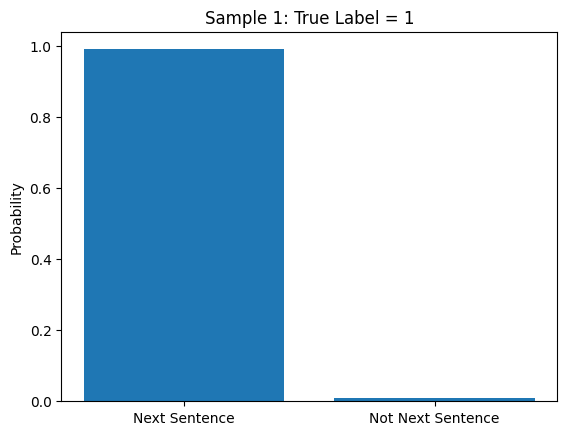

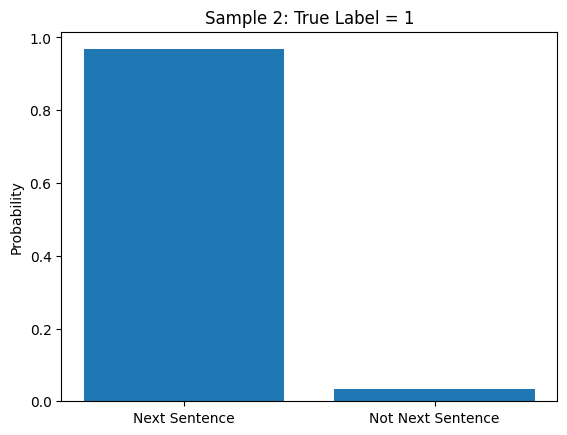

IndexError: index 2 is out of bounds for axis 0 with size 2

In [11]:
# Visualization
predictions = trainer.predict(test_dataset)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

for i in range(5):
    plt.bar(["Next Sentence", "Not Next Sentence"], probs[i])
    plt.title(f"Sample {i+1}: True Label = {test_dataset[i]["label"]}")
    plt.ylabel("Probability")
    plt.show()